In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/all_catalog_test.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [5]:
example_df = dps_df[dps_df['TARGETID']==39627788189175974].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam, flux, ivar = DP_SPECTRA.data_stack[example_idx, 0, :], DP_SPECTRA.data_stack[example_idx, 1, :], DP_SPECTRA.data_stack[example_idx, 2, :]
sigma = 1/np.sqrt(np.abs(ivar))


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_55903/1028261939.py:4: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [6]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

In [7]:
example_df

TARGETID         39627788189175974
RA                      206.441452
DEC                      -0.070261
Z                         0.253147
LOGM                     10.866252
LOGSFR                    1.388264
dv_r                    143.689224
dv_l                    -79.941612
sigma_r                  59.192802
sigma_l                  99.726982
sigma_1comp             149.329239
p_value                        0.0
OII3726_dp                   False
OII3729_dp                   False
Hbeta_dp                     False
OIII4959_dp                  False
OIII5007_dp                  False
NII6548_dp                   False
Halpha_dp                     True
NII6583_dp                    True
SII6716_dp                   False
SII6731_dp                   False
OII3726_rank                     7
OII3729_rank                     6
Hbeta_rank                       2
OIII4959_rank                    9
OIII5007_rank                    8
NII6548_rank                     4
Halpha_rank         

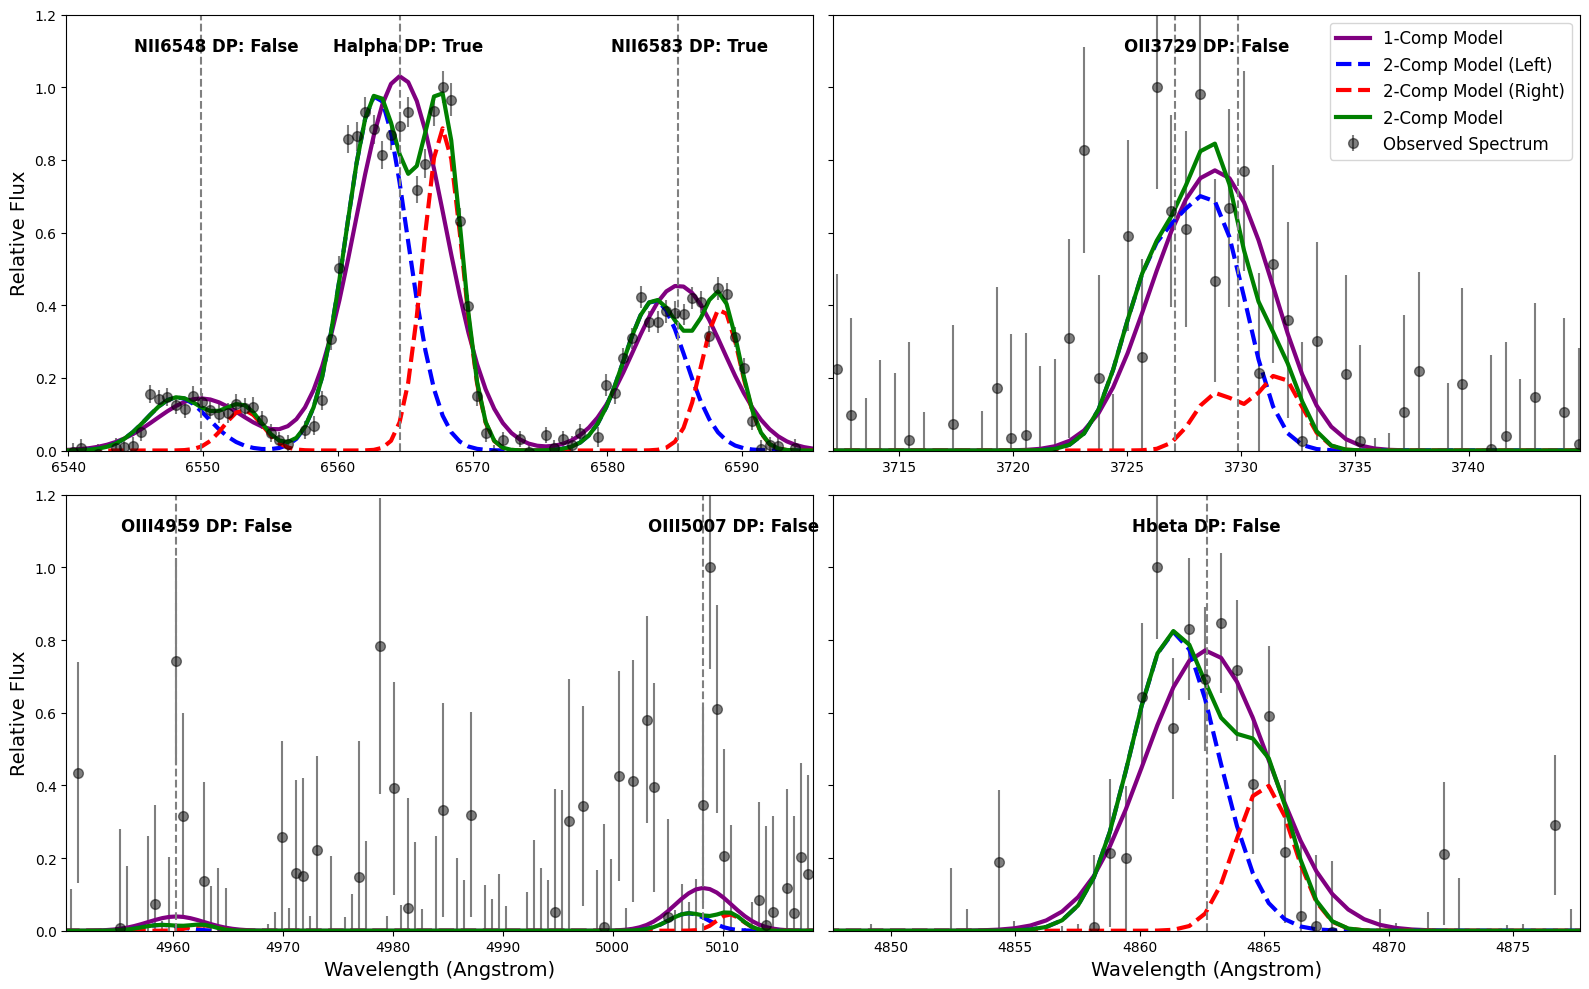

In [8]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

# plt.figure(figsize=(12,6))

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):

    
    # plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
    # plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
    # plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
    # ax.set_xlabel('Wavelength (Angstrom)')
    # ax.set_ylabel('Flux')
    if i == 0:
        ax.set_xlim([NII_rest[0]-10, NII_rest[1]+10])
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 1:
        ax.set_xlim([OII_rest[0]-15, OII_rest[1]+15])
    elif i == 2:
        ax.set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 3:
        ax.set_xlim([Hbeta_rest[0]-15, Hbeta_rest[0]+15])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)

    v_max = np.max(flux[(lam>ax.get_xlim()[0]) & (lam<ax.get_xlim()[1])])
    ax.set_ylim(bottom=0, top=1.2)

    ax.errorbar(lam, flux/v_max, yerr=sigma/v_max, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.5)
    ax.plot(lam, test_1comp/v_max, label='1-Comp Model', linewidth=3, color='purple')
    ax.plot(lam, test_2comp_l/v_max, label='2-Comp Model (Left)', linestyle='--', linewidth=3, color='blue')
    ax.plot(lam, test_2comp_r/v_max, label='2-Comp Model (Right)', linestyle='--', linewidth=3, color='red')
    ax.plot(lam, test_2comp/v_max, label='2-Comp Model', linewidth=3, color='green')

    
    for i, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle='--')
            if i != 0:
                line_label = f'{line_cols[i]} DP: {example_df[line_cols[i]+'_dp']}'
                if i != 2:
                    ax.text(line-5, 1.1, line_label, color='k', fontsize=12, weight='bold')
                else:
                    ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()

plt.show()


In [9]:
print(image_link(example_df['RA'], example_df['DEC'], plot=True, save_image=False, fname=f"./images/{example_df['TARGETID']}_image.jpg"))
print(spectrum_link(example_df['TARGETID']))

https://www.legacysurvey.org/viewer?ra=206.4414520263672&dec=-0.07026122510433197&layer=hsc-dr3&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627788189175974
